# Credit Score vs. Income (DTI proxy) Correlation

**Note on "income":** the Freddie Mac Single-Family Loan-Level Dataset does not include a raw borrower income field. The closest available proxy is **`original_dti`** (original debt-to-income ratio), which is directly computed from the borrower's income (`DTI = monthly debt obligations / monthly gross income`). A *lower* DTI implies *higher* income relative to debt, so we'd expect DTI to correlate *negatively* with credit score if higher-income/lower-risk borrowers also tend to have better credit.

This notebook loads the full processed loan-level dataset (15.4M loans, 2018Q1-2026Q1) and examines the relationship between `credit_score` and `original_dti`, plus a couple of related fields for context.

In [1]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

DATA_GLOB = "../data/processed/loan_level/orig_year=*/orig_quarter=*/*.parquet"
COLUMNS = [
    "loan_sequence_number", "credit_score", "original_dti", "original_upb",
    "original_cltv", "original_interest_rate", "default_target",
    "orig_year", "orig_quarter",
]

df = (
    pl.scan_parquet(DATA_GLOB, extra_columns="ignore")
    .select(COLUMNS)
    .collect()
)
print(f"Loaded {df.height:,} loans")
df.head()

Loaded 15,424,539 loans


loan_sequence_number,credit_score,original_dti,original_upb,original_cltv,original_interest_rate,default_target,orig_year,orig_quarter
str,i64,f64,f64,f64,f64,i32,i32,str
"""F18Q10289921""",685,36.0,483000.0,95.0,4.875,0,2018,"""Q1"""
"""F18Q10289763""",780,22.0,378000.0,90.0,4.125,0,2018,"""Q1"""
"""F18Q10289808""",774,1.0,189000.0,70.0,5.0,0,2018,"""Q1"""
"""F18Q10290338""",703,49.0,168000.0,95.0,4.75,0,2018,"""Q1"""
"""F18Q10290560""",756,44.0,104000.0,80.0,5.875,0,2018,"""Q1"""


## Clean up rows missing either field

`credit_score` and `original_dti` were already sentinel-nulled during preprocessing (see `pipeline/clean.py`), so we just drop rows where either is null for this analysis.

In [2]:
before = df.height
clean = df.drop_nulls(subset=["credit_score", "original_dti"])
print(f"Dropped {before - clean.height:,} rows missing credit_score or original_dti "
      f"({(before - clean.height) / before:.1%})")
print(f"Remaining: {clean.height:,} loans")

clean.select("credit_score", "original_dti", "original_upb", "original_cltv").describe()

Dropped 18,684 rows missing credit_score or original_dti (0.1%)
Remaining: 15,405,855 loans


statistic,credit_score,original_dti,original_upb,original_cltv
str,f64,f64,f64,f64
"""count""",1.5405855e7,1.5405855e7,1.5405855e7,1.5405754e7
"""null_count""",0.0,0.0,0.0,101.0
"""mean""",752.164718,35.031239,289868.933857,72.428218
"""std""",44.431672,9.694909,153882.577916,17.986146
"""min""",300.0,1.0,1000.0,1.0
"""25%""",722.0,28.0,175000.0,61.0
"""50%""",761.0,36.0,260000.0,75.0
"""75%""",788.0,43.0,377000.0,85.0
"""max""",850.0,65.0,2.3e6,365.0


## Correlation: credit score vs. DTI (and related fields)

In [3]:
corr_fields = ["credit_score", "original_dti", "original_upb", "original_cltv", "original_interest_rate"]

pearson_r = clean.select(pl.corr("credit_score", "original_dti")).item()
print(f"Pearson correlation (credit_score, original_dti): {pearson_r:.4f}")

# `clean` only dropped nulls for credit_score/original_dti. Other fields in corr_fields
# (e.g. original_cltv, 18 nulls) can still contain nulls -> NaN once converted to numpy,
# and np.corrcoef propagates a single NaN across that whole column's correlations. Drop
# nulls across all corr_fields specifically for the matrix.
corr_clean = df.drop_nulls(subset=corr_fields)
print(f"Rows used for correlation matrix: {corr_clean.height:,} "
      f"(dropped {df.height - corr_clean.height:,} additional rows with nulls in any of {corr_fields})")

corr_matrix = np.corrcoef(corr_clean.select(corr_fields).to_numpy(), rowvar=False)
corr_df = pl.DataFrame({"field": corr_fields, **{f: corr_matrix[:, i] for i, f in enumerate(corr_fields)}})
corr_df

Pearson correlation (credit_score, original_dti): -0.1601
Rows used for correlation matrix: 15,405,754 (dropped 18,785 additional rows with nulls in any of ['credit_score', 'original_dti', 'original_upb', 'original_cltv', 'original_interest_rate'])


field,credit_score,original_dti,original_upb,original_cltv,original_interest_rate
str,f64,f64,f64,f64,f64
"""credit_score""",1.0,-0.16012,0.107708,-0.078807,-0.106839
"""original_dti""",-0.16012,1.0,0.101113,0.138217,0.198012
"""original_upb""",0.107708,0.101113,1.0,0.170599,0.053924
"""original_cltv""",-0.078807,0.138217,0.170599,1.0,0.178835
"""original_interest_rate""",-0.106839,0.198012,0.053924,0.178835,1.0


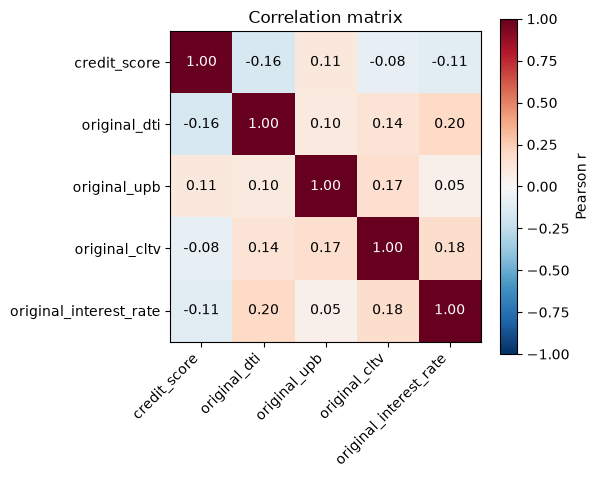

In [4]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr_matrix, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_fields)))
ax.set_yticks(range(len(corr_fields)))
ax.set_xticklabels(corr_fields, rotation=45, ha="right")
ax.set_yticklabels(corr_fields)
for i in range(len(corr_fields)):
    for j in range(len(corr_fields)):
        ax.text(j, i, f"{corr_matrix[i, j]:.2f}", ha="center", va="center",
                 color="white" if abs(corr_matrix[i, j]) > 0.5 else "black")
fig.colorbar(im, ax=ax, label="Pearson r")
ax.set_title("Correlation matrix")
fig.tight_layout()
plt.show()

## Scatter plot (sampled) with trend line

Plotting all 15M+ points would be unreadable and slow, so we take a random sample of 50,000 loans just for visualization -- the correlation coefficient above is already computed on the full dataset.

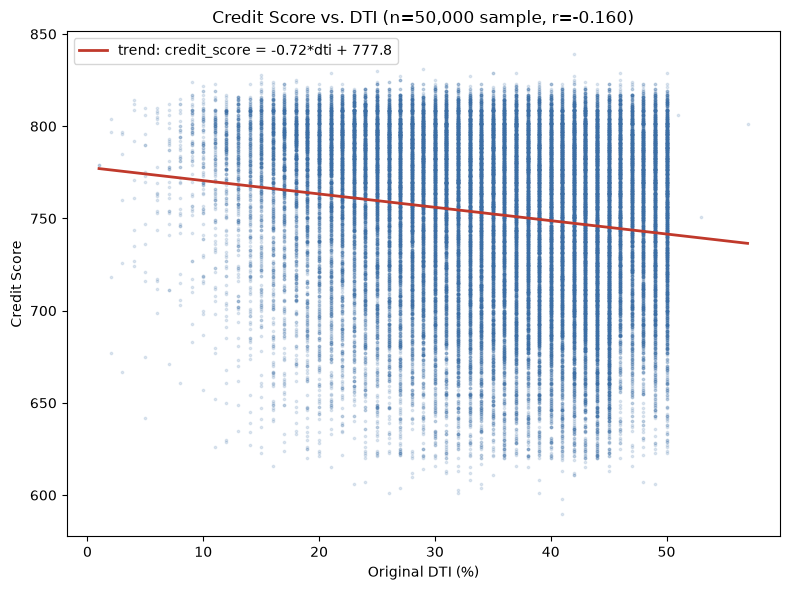

In [5]:
sample = clean.sample(n=50_000, seed=42)
x = sample["original_dti"].to_numpy()
y = sample["credit_score"].to_numpy()

slope, intercept = np.polyfit(x, y, 1)
xs = np.linspace(x.min(), x.max(), 100)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(x, y, s=3, alpha=0.15, color="#3b6ea5")
ax.plot(xs, slope * xs + intercept, color="#c0392b", linewidth=2,
        label=f"trend: credit_score = {slope:.2f}*dti + {intercept:.1f}")
ax.set_xlabel("Original DTI (%)")
ax.set_ylabel("Credit Score")
ax.set_title(f"Credit Score vs. DTI (n=50,000 sample, r={pearson_r:.3f})")
ax.legend()
fig.tight_layout()
plt.show()

## Binned view: average DTI by credit score bucket

A scatter of 50,000 overlapping points can be hard to read even with transparency. Bucketing credit score into 20-point bins and averaging DTI within each bucket makes the relationship's shape clearer.

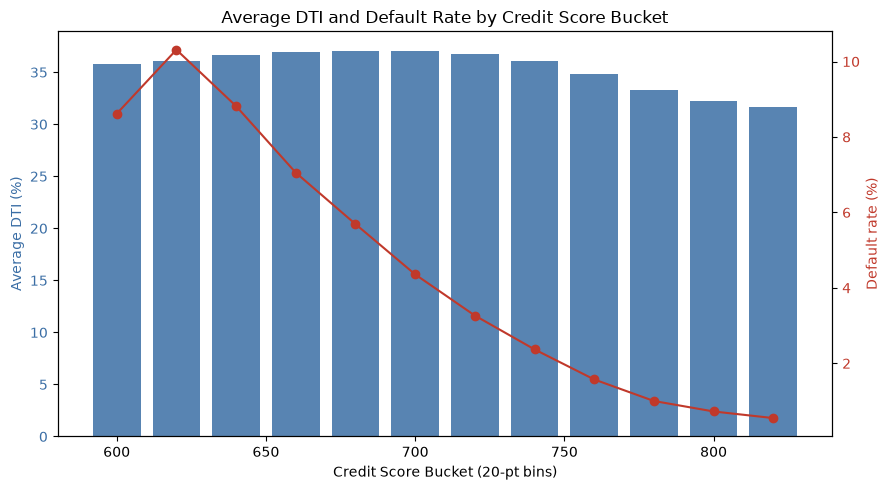

credit_score_bucket,avg_dti,n_loans,default_rate
i64,f64,u32,f64
600,35.76621,13649,0.08616
620,36.107802,189161,0.103119
640,36.649638,349935,0.088177
660,36.930941,595854,0.070539
680,37.074973,1046696,0.056912
…,…,…,…
740,36.052745,2144962,0.023696
760,34.801502,2681962,0.015724
780,33.29001,3155403,0.010017


In [6]:
binned = (
    clean
    .with_columns(
        ((pl.col("credit_score") // 20) * 20).alias("credit_score_bucket")
    )
    .group_by("credit_score_bucket")
    .agg(
        avg_dti=pl.col("original_dti").mean(),
        n_loans=pl.len(),
        default_rate=pl.col("default_target").mean(),
    )
    .filter(pl.col("n_loans") >= 1000)  # drop sparse buckets at the tails
    .sort("credit_score_bucket")
)

fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.bar(binned["credit_score_bucket"], binned["avg_dti"], width=16, color="#3b6ea5", alpha=0.85, label="Avg DTI")
ax1.set_xlabel("Credit Score Bucket (20-pt bins)")
ax1.set_ylabel("Average DTI (%)", color="#3b6ea5")
ax1.tick_params(axis="y", labelcolor="#3b6ea5")

ax2 = ax1.twinx()
ax2.plot(binned["credit_score_bucket"], binned["default_rate"] * 100, color="#c0392b", marker="o", label="Default rate")
ax2.set_ylabel("Default rate (%)", color="#c0392b")
ax2.tick_params(axis="y", labelcolor="#c0392b")

ax1.set_title("Average DTI and Default Rate by Credit Score Bucket")
fig.tight_layout()
plt.show()

binned

## Interpretation

Run the notebook and check the printed Pearson `r` above:

- **r close to 0** (roughly -0.1 to 0.1): credit score and DTI are essentially uncorrelated in this dataset -- underwriting treats them as largely independent risk factors, which is consistent with how mortgage guidelines actually work (DTI and credit score are separate underwriting criteria, not derived from one another).
- **r moderately negative** (e.g. -0.2 to -0.4): borrowers with better credit tend to carry somewhat lower DTI, plausible if higher-income/more-creditworthy borrowers can afford lower debt loads.
- The **binned chart** is usually more informative than the raw correlation here, since it also overlays default rate -- if default rate rises sharply as credit score drops (expected) while avg DTI stays relatively flat across buckets, that's evidence DTI and credit score are independent inputs to risk rather than proxies for the same thing.

Remember: `original_dti` is a *ratio*, not raw income -- two borrowers with identical DTI can have very different absolute income levels. If true income analysis is needed, it isn't available in this dataset and would require an external data source joined in by borrower/loan.

## Appendix: replicating a friend's "estimated_annual_income" analysis

A friend working from the **same dataset** produced a correlation heatmap that included `estimated_annual_income` and `loan_to_income_ratio`. Since this dataset has no raw income field, those columns must be *derived*, not measured. The standard way to back into an income estimate from mortgage data is:

1. Compute the **monthly mortgage payment** from `original_upb`, `original_interest_rate`, `original_loan_term` using the standard amortization formula.
2. Treat that payment as (approximately) the debt obligation behind `original_dti`, so: `estimated_monthly_income = monthly_payment / (original_dti / 100)`, then annualize.
3. `loan_to_income_ratio = original_upb / estimated_annual_income`.

**Important caveats before trusting this:**
- **It's circular by construction.** `estimated_annual_income` is *computed from* `original_dti`, so any correlation between `estimated_annual_income` (or `loan_to_income_ratio`) and `original_dti` is partly definitional, not an independent finding. That's almost certainly why the friend's heatmap showed `loan_to_income_ratio` correlating 0.84 with `original_dti_ratio` -- they're mechanically linked, not two separately-measured quantities agreeing.
- **DTI usually includes *all* debt** (credit cards, auto loans, other mortgages), not just this mortgage payment. Using only the mortgage payment as the numerator means this systematically *overestimates* income for borrowers who have significant other debt.
- **Extreme outliers near DTI's low end.** A handful of loans have `original_dti` as low as 1%, which blows up the estimate (max ~$9.1M/year on a $270K median-UPB dataset). We filter `original_dti < 5` (8,652 of 12.2M rows, 0.07%) before computing correlations to avoid a few outliers dominating the result.

Treat this section as **an approximation for comparison purposes**, not a real income signal.

In [7]:
income_fields = ["credit_score", "original_upb", "original_dti", "original_ltv", "original_interest_rate", "original_loan_term"]
income_df = (
    pl.scan_parquet(DATA_GLOB, extra_columns="ignore")
    .select(income_fields)
    .collect()
    .drop_nulls()
    .filter(pl.col("original_dti") >= 5)  # drop the near-zero-DTI outlier tail (see caveats above)
)
print(f"Rows after filtering: {income_df.height:,}")

monthly_rate = income_df["original_interest_rate"] / 100 / 12
n_payments = income_df["original_loan_term"]
monthly_payment = income_df["original_upb"] * monthly_rate / (1 - (1 + monthly_rate) ** (-n_payments))
estimated_monthly_income = monthly_payment / (income_df["original_dti"] / 100)

income_df = income_df.with_columns(
    (estimated_monthly_income * 12).alias("estimated_annual_income")
).with_columns(
    (pl.col("original_upb") / pl.col("estimated_annual_income")).alias("loan_to_income_ratio")
)

income_df.select("estimated_annual_income", "loan_to_income_ratio").describe()

Rows after filtering: 15,399,056


statistic,estimated_annual_income,loan_to_income_ratio
str,f64,f64
"""count""",1.5399056e7,1.5399056e7
"""null_count""",0.0,0.0
"""mean""",NaN,NaN
"""std""",NaN,NaN
"""min""",148.136613,0.329246
"""25%""",31187.878106,4.32514
"""50%""",47432.099485,5.653798
"""75%""",71321.916295,7.029014
"""max""",2.9636e6,13.486019


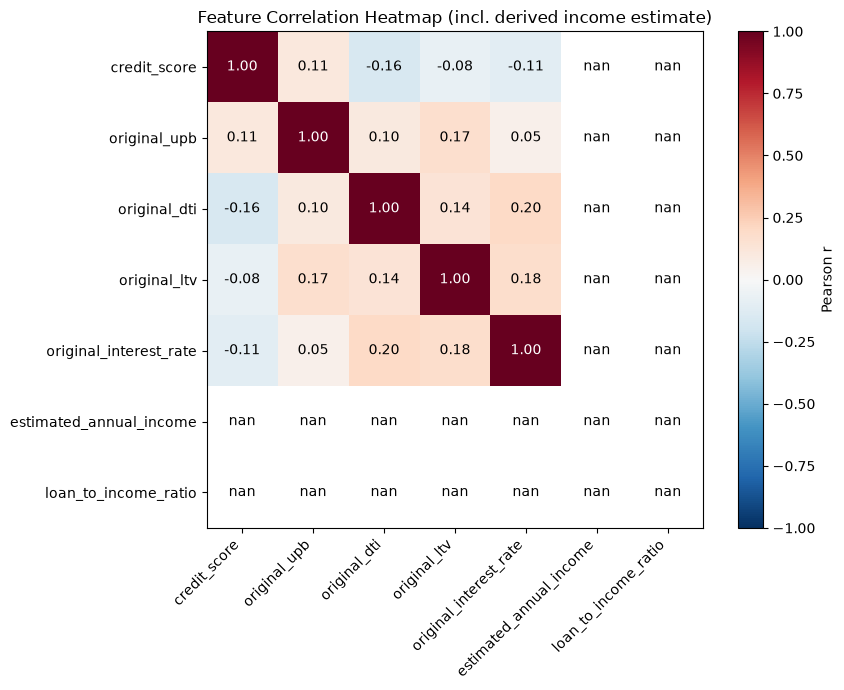

field,credit_score,original_upb,original_dti,original_ltv,original_interest_rate,estimated_annual_income,loan_to_income_ratio
str,f64,f64,f64,f64,f64,f64,f64
"""credit_score""",1.0,0.107751,-0.16019,-0.077491,-0.106826,NaN,NaN
"""original_upb""",0.107751,1.0,0.101417,0.166103,0.053968,NaN,NaN
"""original_dti""",-0.16019,0.101417,1.0,0.136637,0.198576,NaN,NaN
"""original_ltv""",-0.077491,0.166103,0.136637,1.0,0.178776,NaN,NaN
"""original_interest_rate""",-0.106826,0.053968,0.198576,0.178776,1.0,NaN,NaN
"""estimated_annual_income""",NaN,NaN,NaN,NaN,NaN,NaN,NaN
"""loan_to_income_ratio""",NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
extended_fields = [
    "credit_score", "original_upb", "original_dti", "original_ltv",
    "original_interest_rate", "estimated_annual_income", "loan_to_income_ratio",
]
extended_matrix = np.corrcoef(income_df.select(extended_fields).to_numpy(), rowvar=False)

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(extended_matrix, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(extended_fields)))
ax.set_yticks(range(len(extended_fields)))
ax.set_xticklabels(extended_fields, rotation=45, ha="right")
ax.set_yticklabels(extended_fields)
for i in range(len(extended_fields)):
    for j in range(len(extended_fields)):
        ax.text(j, i, f"{extended_matrix[i, j]:.2f}", ha="center", va="center",
                 color="white" if abs(extended_matrix[i, j]) > 0.5 else "black")
fig.colorbar(im, ax=ax, label="Pearson r")
ax.set_title("Feature Correlation Heatmap (incl. derived income estimate)")
fig.tight_layout()
plt.show()

pl.DataFrame({"field": extended_fields, **{f: extended_matrix[:, i] for i, f in enumerate(extended_fields)}})